# Visual Evaluation Notebook for Qwen3 4B / 0.6B

This notebook is dedicated to visual evaluation for the Qwen3 review outputs and reads CSV files directly from `Review/results/`.
It provides an integrated workflow for configuration-level comparison, task-level comparison, Pareto analysis, acceptance-rate analysis, speed distribution analysis, and consolidated exports.

## 1) Environment Setup

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
project_root = cwd
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src").exists() and (candidate / "results").exists():
        project_root = candidate
        break

src_dir = str(project_root / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Results dir exists: {(project_root / 'Review' / 'results').exists()}")

Project root: C:\Working\speculative-decoding-main_v10\speculative-decoding-main
Results dir exists: True


In [2]:
import importlib
import os
import sys

review_root = project_root / "Review"
review_results_dir = review_root / "results"
review_figures_dir = review_root / "figures"
review_stability_dir = review_results_dir / "stability"
review_drifter_dir = review_results_dir / "drifter_ckpt"

qwen3_target_model_id = "Qwen/Qwen3-4B"
qwen3_draft_model_id = "Qwen/Qwen3-0.6B"

os.environ["SPECDEC_TARGET_MODEL_ID"] = qwen3_target_model_id
os.environ["SPECDEC_DRAFT_MODEL_ID"] = qwen3_draft_model_id
os.environ["SPECDEC_RESULTS_DIR"] = str(review_results_dir)
os.environ["SPECDEC_STABILITY_DIR"] = str(review_stability_dir)
os.environ["SPECDEC_FIGURES_DIR"] = str(review_figures_dir)
os.environ["SPECDEC_DRIFTER_CHECKPOINT_DIR"] = str(review_drifter_dir)
os.environ["SPECDEC_TARGET_QUANT"] = "fp16"
os.environ["SPECDEC_DRAFT_QUANT"] = "fp16"
os.environ["SPECDEC_ACSD_PRIMARY_DRAFT"] = "0.6B"
os.environ["SPECDEC_ACSD_RESCUE_DRAFT"] = "0.6B"

config_module = sys.modules.get("config")
if config_module is None:
    import config as config_module
config_module = importlib.reload(config_module)

globals().update({
    "TARGET_MODEL_ID": config_module.TARGET_MODEL_ID,
    "DRAFT_MODELS": config_module.DRAFT_MODELS,
    "RESULTS_DIR": config_module.RESULTS_DIR,
    "STABILITY_DIR": config_module.STABILITY_DIR,
    "FIGURES_DIR": config_module.FIGURES_DIR,
    "TARGET_QUANT": config_module.TARGET_QUANT,
    "DRAFT_QUANT": config_module.DRAFT_QUANT,
})
if hasattr(config_module, "ACSD_EVAL"):
    globals()["ACSD_EVAL"] = config_module.ACSD_EVAL

for module_name in ("runtime", "baseline", "speculative", "acsd", "hf_assistant", "drift_speculative"):
    module = sys.modules.get(module_name)
    if module is not None:
        importlib.reload(module)

## 2) Load Unified Visual Evaluation Backend

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from visual_eval_backend import (
    load_visual_evaluation,
    export_summary_tables,
    export_all_figures,
    plot_speedup_by_config,
    plot_pareto_speedup_vs_disagreement,
    plot_acceptance_heatmap,
    plot_task_speedup_heatmap,
    plot_speedup_distribution,
    plot_latency_gain_vs_acceptance,
)

results_dir = project_root / 'Review' / 'results'
bundle = load_visual_evaluation(results_dir)

print(f'Discovered CSV files: {len(bundle.discovered_files)}')
print(f'Baseline rows: {len(bundle.baseline_df)}')
print(f'Spec rows: {len(bundle.spec_df)}')
print(f'Paired rows: {len(bundle.merged_df)}')

Discovered CSV files: 8
Baseline rows: 2000
Spec rows: 6000
Paired rows: 6000


## 3) Summary Tables

In [4]:
if bundle.run_summary.empty:
    print('No speculative summary data found in results/.')
else:
    print('Run-level summary (sorted by speedup_mean):')
    display(bundle.run_summary)

if bundle.task_summary.empty:
    print('No task-level summary data found in results/.')
else:
    print('Task-level summary:')
    display(bundle.task_summary)

Run-level summary (sorted by speedup_mean):


,config,draft,k,regime,n_samples,n_tasks,latency_mean_s,baseline_latency_mean_s,speedup_mean,speedup_median,...,speedup_p90,ttft_mean_ms,tpot_mean_ms,tokens_per_sec_mean,baseline_tokens_per_sec_mean,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,0.6B_k4_deterministic,0.6B,4,deterministic,1000,3,6.496462,4.380503,0.656162,0.656821,...,0.843886,224.25396,53.70059,18.77522,28.70402,0.335268,1.31056,1.000,1.0,100.0
1,0.6B_k4_stochastic,0.6B,4,stochastic,1000,3,7.428401,4.400608,0.592332,0.576184,...,0.757501,226.56774,59.42932,16.85750,28.57081,0.284531,1.11043,1.000,1.0,100.0
2,0.6B_k8_deterministic,0.6B,8,deterministic,1000,3,9.496679,4.380503,0.468388,0.452651,...,0.657413,325.50030,78.03342,13.40700,28.70402,0.253779,1.92680,1.000,1.0,100.0
3,0.6B_k8_stochastic,0.6B,8,stochastic,1000,3,11.014136,4.400608,0.427636,0.404152,...,0.600343,329.61943,85.55164,12.19716,28.57081,0.227319,1.70868,1.000,1.0,100.0
4,0.6B_k16_deterministic,0.6B,16,deterministic,1000,3,16.925232,4.380503,0.316143,0.277652,...,0.522247,523.59527,125.61892,9.06011,28.70402,0.180275,2.45918,0.999,1.0,99.9
5,0.6B_k16_stochastic,0.6B,16,stochastic,1000,3,19.806433,4.400608,0.273982,0.230222,...,0.462689,538.11503,145.69116,7.82637,28.57081,0.154329,2.10093,0.999,1.0,99.9


Task-level summary:


,config,draft,k,regime,task,n_samples,speedup_mean,speedup_median,latency_mean_s,baseline_latency_mean_s,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,0.6B_k4_deterministic,0.6B,4,deterministic,cnndm,200,0.776688,0.775911,7.846720,6.003041,0.419760,1.665900,1.000,1.0,100.0
1,0.6B_k4_stochastic,0.6B,4,stochastic,cnndm,200,0.721943,0.721740,8.572490,6.065168,0.370673,1.471850,1.000,1.0,100.0
2,0.6B_k8_deterministic,0.6B,8,deterministic,cnndm,200,0.549221,0.533532,11.303006,6.003041,0.293780,2.311350,1.000,1.0,100.0
3,0.6B_k8_stochastic,0.6B,8,stochastic,cnndm,200,0.477345,0.466885,13.323956,6.065168,0.240187,1.887950,1.000,1.0,100.0
4,0.6B_k16_deterministic,0.6B,16,deterministic,cnndm,200,0.321530,0.307283,20.095908,6.003041,0.167444,2.582050,1.000,1.0,100.0
5,0.6B_k16_stochastic,0.6B,16,stochastic,cnndm,200,0.273549,0.253022,24.161993,6.065168,0.138591,2.129600,1.000,1.0,100.0
6,0.6B_k4_deterministic,0.6B,4,deterministic,gsm8k,300,0.686464,0.675959,13.166134,8.771363,0.342282,1.363533,1.000,1.0,100.0
7,0.6B_k4_stochastic,0.6B,4,stochastic,gsm8k,300,0.572378,0.561310,15.578644,8.789811,0.250836,0.998700,1.000,1.0,100.0
8,0.6B_k8_deterministic,0.6B,8,deterministic,gsm8k,300,0.480030,0.454395,19.359368,8.771363,0.253572,2.008233,1.000,1.0,100.0
9,0.6B_k8_stochastic,0.6B,8,stochastic,gsm8k,300,0.398635,0.380044,22.989427,8.789811,0.195328,1.545600,1.000,1.0,100.0


## 4) Core Visualizations

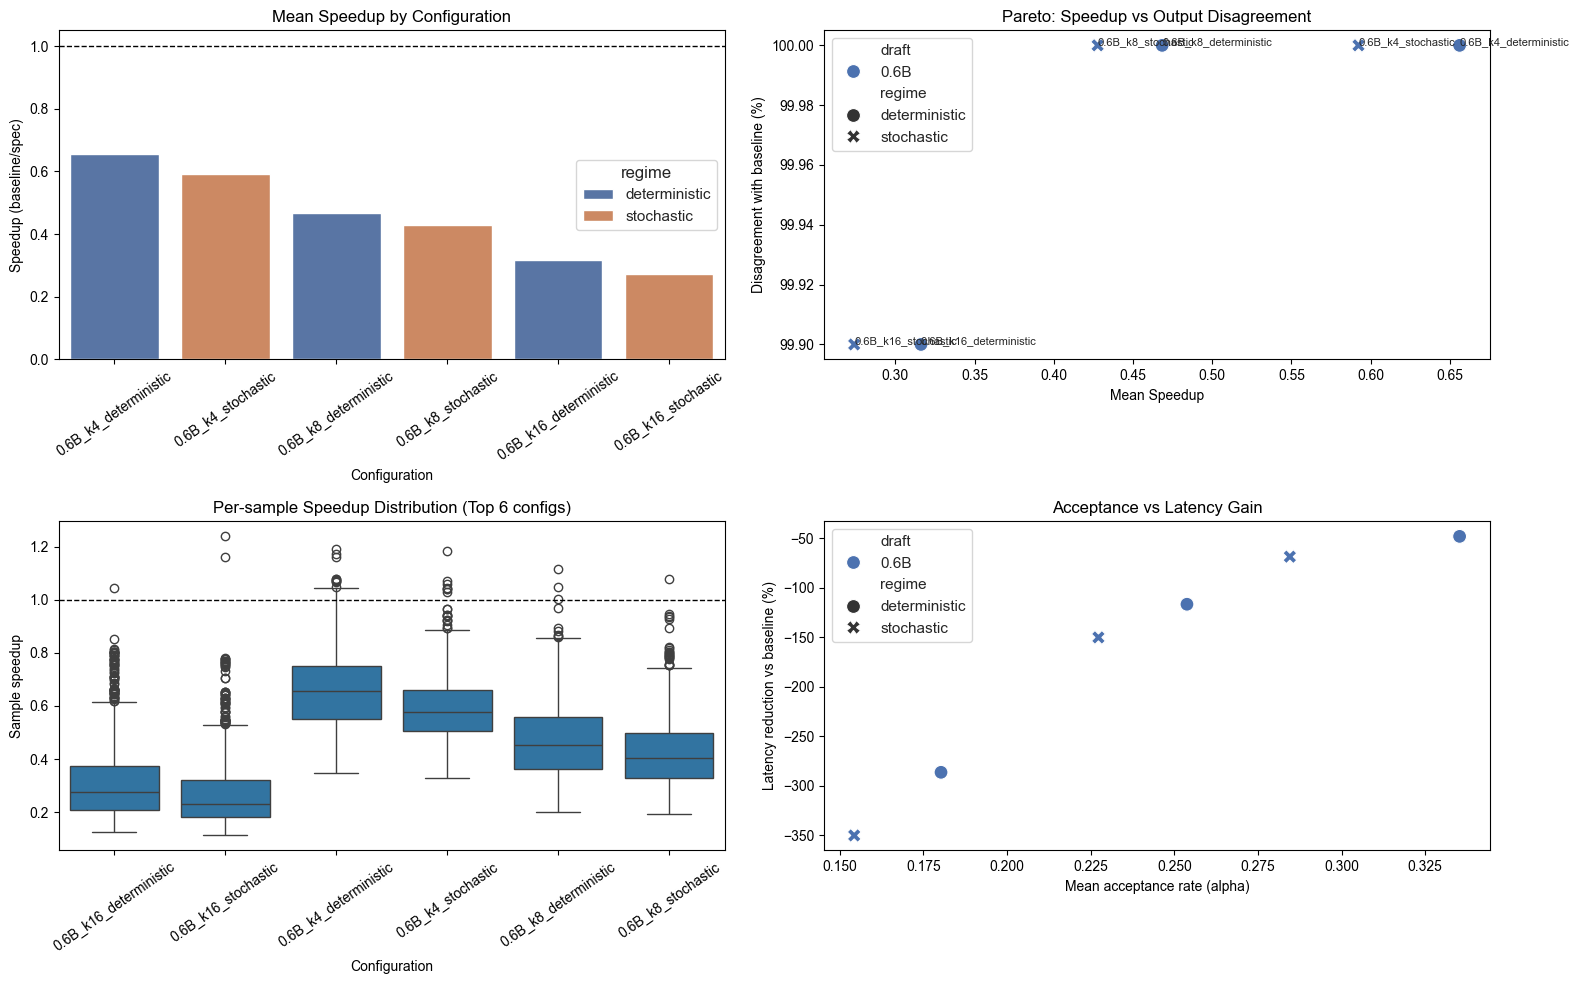

In [5]:
if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Insufficient data for plotting. Ensure baseline_*.csv and spec_*.csv exist in results/.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plot_speedup_by_config(bundle.run_summary, ax=axes[0, 0])
    plot_pareto_speedup_vs_disagreement(bundle.run_summary, ax=axes[0, 1])
    plot_speedup_distribution(bundle.merged_df, top_configs=6, ax=axes[1, 0])
    plot_latency_gain_vs_acceptance(bundle.run_summary, ax=axes[1, 1])
    fig.tight_layout()
    plt.show()

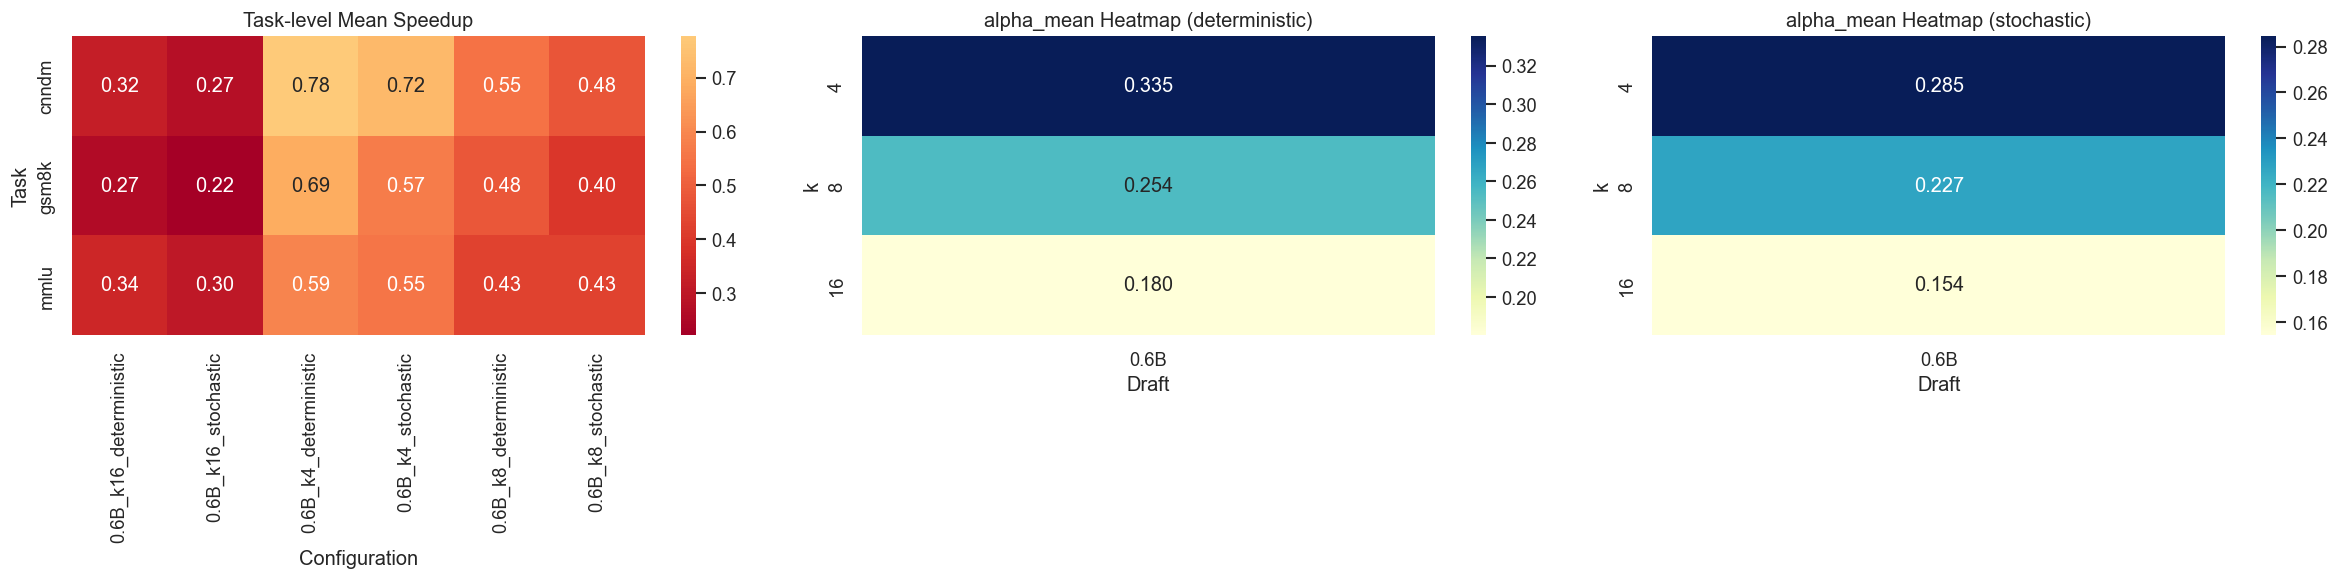

In [6]:
if bundle.run_summary.empty or bundle.task_summary.empty:
    print('Insufficient summary data for heatmaps.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    plot_task_speedup_heatmap(bundle.task_summary, ax=axes[0])

    regimes = list(bundle.run_summary['regime'].dropna().unique())
    if 'deterministic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='deterministic', metric='alpha_mean', ax=axes[1])
    else:
        axes[1].set_axis_off()
        axes[1].set_title('No deterministic data')

    if 'stochastic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='stochastic', metric='alpha_mean', ax=axes[2])
    else:
        axes[2].set_axis_off()
        axes[2].set_title('No stochastic data')

    fig.tight_layout()
    plt.show()

## 5) Export Tables and Figures

In [7]:
export_dir = results_dir / 'visual_eval'
export_dir.mkdir(parents=True, exist_ok=True)

table_paths = export_summary_tables(bundle, export_dir)
print('Exported tables:')
for name, p in table_paths.items():
    print(f'  {name}: {p}')

if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Skipped figure export due to missing plotting data.')
else:
    fig_paths = export_all_figures(bundle, export_dir)
    print('Exported figures:')
    for name, p in fig_paths.items():
        print(f'  {name}: {p}')

Exported tables:
  run_summary: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\run_summary.csv
  task_summary: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\task_summary.csv
  pairwise_sample_metrics: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\pairwise_sample_metrics.csv
Exported figures:
  speedup_by_config: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\speedup_by_config.png
  pareto_speedup_vs_disagreement: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\pareto_speedup_vs_disagreement.png
  acceptance_heatmaps: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\acceptance_heatmaps.png
  task_speedup_heatmap: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\visual_eval\task_

## 6) Quick Interpretation Helper

Recommended reading order for the Qwen3 4B target / Qwen3 0.6B draft review set:
1. Check `speedup_mean` and `disagreement_rate_pct` in `run_summary`.
2. In the Pareto chart, identify configurations with high speedup and low disagreement.
3. In the task heatmap, check for task-level regressions (for example, unstable speedup on specific tasks).